In [74]:
import requests
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


#Task 1: Build the Data Collection Pipeline

# Step 1: Collect API Data

In [75]:
# Collect API Data
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)
data = response.json()
repos = data['items']
print(data)

{'total_count': 1229284, 'incomplete_results': False, 'items': [{'id': 45717250, 'node_id': 'MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==', 'name': 'tensorflow', 'full_name': 'tensorflow/tensorflow', 'private': False, 'owner': {'login': 'tensorflow', 'id': 15658638, 'node_id': 'MDEyOk9yZ2FuaXphdGlvbjE1NjU4NjM4', 'avatar_url': 'https://avatars.githubusercontent.com/u/15658638?v=4', 'gravatar_id': '', 'url': 'https://api.github.com/users/tensorflow', 'html_url': 'https://github.com/tensorflow', 'followers_url': 'https://api.github.com/users/tensorflow/followers', 'following_url': 'https://api.github.com/users/tensorflow/following{/other_user}', 'gists_url': 'https://api.github.com/users/tensorflow/gists{/gist_id}', 'starred_url': 'https://api.github.com/users/tensorflow/starred{/owner}{/repo}', 'subscriptions_url': 'https://api.github.com/users/tensorflow/subscriptions', 'organizations_url': 'https://api.github.com/users/tensorflow/orgs', 'repos_url': 'https://api.github.com/users/tensorflow/repos',

#Step 2: Create the Dataset

In [76]:
df = pd.DataFrame(repos)
print(df.head())
df.info()

          id                           node_id                      name  \
0   45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==                tensorflow   
1  155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=              transformers   
2  343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=          ML-For-Beginners   
3  145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=                    funNLP   
4   21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==  awesome-machine-learning   

                               full_name  private  \
0                  tensorflow/tensorflow    False   
1               huggingface/transformers    False   
2             microsoft/ML-For-Beginners    False   
3                  fighting41love/funNLP    False   
4  josephmisiti/awesome-machine-learning    False   

                                               owner  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...   
1  {'login': 'huggingface', 'id': 25720743, 'node...   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...   


#Step 3: Select Required Columns


In [77]:
required_columns = [
    'name',
    'owner',
    'language',
    'stargazers_count',
    'forks_count',
    'watchers_count',
    'open_issues_count',
    'created_at',
    'updated_at',
    'license'
]

df = df[required_columns]

print(df.head())

                       name  \
0                tensorflow   
1              transformers   
2          ML-For-Beginners   
3                    funNLP   
4  awesome-machine-learning   

                                               owner          language  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...               C++   
1  {'login': 'huggingface', 'id': 25720743, 'node...            Python   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...  Jupyter Notebook   
3  {'login': 'fighting41love', 'id': 11475294, 'n...            Python   
4  {'login': 'josephmisiti', 'id': 246302, 'node_...            Python   

   stargazers_count  forks_count  watchers_count  open_issues_count  \
0            197087        76060          197087               2868   
1            164166        34256          164166               2384   
2             89443        21953           89443                 11   
3             82501        15267           82501                 53   
4            

#Step 4: Extract Required Values

In [78]:
# Function to extract owner username safely
def get_owner_login(x):
    if isinstance(x, dict) and 'login' in x:
        return x['login']
    return None

# Function to extract license key safely
def get_license_key(x):
    if isinstance(x, dict) and 'key' in x:
        return x['key']
    return None

# Apply the functions to extract nested values
df['owner'] = df['owner'].apply(get_owner_login)
df['license'] = df['license'].apply(get_license_key)

# Preview the clean DataFrame
print(df.head())

                       name           owner          language  \
0                tensorflow      tensorflow               C++   
1              transformers     huggingface            Python   
2          ML-For-Beginners       microsoft  Jupyter Notebook   
3                    funNLP  fighting41love            Python   
4  awesome-machine-learning    josephmisiti            Python   

   stargazers_count  forks_count  watchers_count  open_issues_count  \
0            197087        76060          197087               2868   
1            164166        34256          164166               2384   
2             89443        21953           89443                 11   
3             82501        15267           82501                 53   
4             74036        15612           74036                 24   

             created_at            updated_at     license  
0  2015-11-07T01:19:20Z  2026-08-16T22:40:49Z  apache-2.0  
1  2018-10-29T13:56:00Z  2026-08-16T22:54:55Z  apache-2.0  
2 

#Step 5: Handle Missing Values

In [79]:
# Check missing values in each column
print(df.isnull().sum())

# Fill missing values in language and license columns
df['language'] = df['language'].fillna('Unknown')
df['license'] = df['license'].fillna('None')

# Verify that missing values are handled
print(df.isnull().sum())

name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64
name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


#Step 6: Handle Duplicate Records

In [80]:
# Check the number of duplicate rows based on repository name
duplicate_count = df.duplicated(subset=['name']).sum()
print("Number of duplicate repositories:", duplicate_count)

# Drop duplicate rows if any exist, keeping the first occurrence
df = df.drop_duplicates(subset=['name'], keep='first')

# Reset the index after dropping duplicates
df = df.reset_index(drop=True)

# Verify dataset shape
print("Dataset shape after removing duplicates:", df.shape)

Number of duplicate repositories: 1
Dataset shape after removing duplicates: (99, 10)


#Step 7: Prepare the Dataset


In [81]:
# Convert date columns to datetime format
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

# Rename columns for clarity and easier SQL usage
df = df.rename(columns={
    'stargazers_count': 'stars',
    'forks_count': 'forks',
    'watchers_count': 'watchers',
    'open_issues_count': 'open_issues',
    'created_at': 'created_date',
    'updated_at': 'updated_date'
})

# Verify column names and data types
print(df.dtypes)
print(df.head())

name                         object
owner                        object
language                     object
stars                         int64
forks                         int64
watchers                      int64
open_issues                   int64
created_date    datetime64[ns, UTC]
updated_date    datetime64[ns, UTC]
license                      object
dtype: object
                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197087  76060   
1              transformers     huggingface            Python  164166  34256   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89443  21953   
3                    funNLP  fighting41love            Python   82501  15267   
4  awesome-machine-learning    josephmisiti            Python   74036  15612   

   watchers  open_issues              created_date              updated_date  \
0    197087         2868 2015-11-07 01:19:20+00:00 2026-08-16 22:

#Step 8: Save and Verify the Dataset


In [82]:
# Save the prepared DataFrame to a CSV file
df.to_csv('github_projects.csv', index=False)

# Reload the CSV file to verify it was saved correctly
df_verified = pd.read_csv('github_projects.csv')

# Verify the shape and first few rows of the reloaded data
print("Saved dataset shape:", df_verified.shape)
print(df_verified.head())

Saved dataset shape: (99, 10)
                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197087  76060   
1              transformers     huggingface            Python  164166  34256   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89443  21953   
3                    funNLP  fighting41love            Python   82501  15267   
4  awesome-machine-learning    josephmisiti            Python   74036  15612   

   watchers  open_issues               created_date  \
0    197087         2868  2015-11-07 01:19:20+00:00   
1    164166         2384  2018-10-29 13:56:00+00:00   
2     89443           11  2021-03-03 01:34:05+00:00   
3     82501           53  2018-08-21 11:20:39+00:00   
4     74036           24  2014-07-15 19:11:19+00:00   

                updated_date     license  
0  2026-08-16 22:40:49+00:00  apache-2.0  
1  2026-08-16 22:54:55+00:00  apache-2.0  
2  2026-08-16 23:13:57+00:00 

#Task 2 Store & Analyse the Data

#Step 1: Create the SQLite Database

In [83]:
# Load the saved CSV file
df = pd.read_csv('github_projects.csv')

# Connect to SQLite database (creates 'github_data.db' if it doesn't exist)
conn = sqlite3.connect('github_data.db')

# Store the DataFrame into an SQL table named 'Repositories'
df.to_sql('Repositories', conn, if_exists='replace', index=False)

# Verify the table was created by running a quick count query
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM Repositories;")
row_count = cursor.fetchone()[0]

print("Successfully inserted rows into Repositories table:", row_count)

Successfully inserted rows into Repositories table: 99


#Step 2: Filtering & Searching Queries

In [84]:
# Query 1: Repositories with more than 10,000 stars
query_stars = """
SELECT *
FROM Repositories
WHERE stars > 10000;
"""
df_stars = pd.read_sql_query(query_stars, conn)
print("Repositories with > 10,000 stars:", len(df_stars))
print(df_stars.head())
print()
# Query 2: Repositories containing 'Machine' in their name
query_machine = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';
"""
df_machine = pd.read_sql_query(query_machine, conn)
print("Repositories containing 'Machine':", len(df_machine))
print(df_machine.head())

Repositories with > 10,000 stars: 70
                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197087  76060   
1              transformers     huggingface            Python  164166  34256   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89443  21953   
3                    funNLP  fighting41love            Python   82501  15267   
4  awesome-machine-learning    josephmisiti            Python   74036  15612   

   watchers  open_issues               created_date  \
0    197087         2868  2015-11-07 01:19:20+00:00   
1    164166         2384  2018-10-29 13:56:00+00:00   
2     89443           11  2021-03-03 01:34:05+00:00   
3     82501           53  2018-08-21 11:20:39+00:00   
4     74036           24  2014-07-15 19:11:19+00:00   

                updated_date     license  
0  2026-08-16 22:40:49+00:00  apache-2.0  
1  2026-08-16 22:54:55+00:00  apache-2.0  
2  2026-08-16 23:13:57

#Step 3: Logical Operators

In [85]:
# Query 1: Filter Python repos with > 50k stars and <= 500 open issues
query_logical_1 = """
SELECT name, language, stars, open_issues
FROM Repositories
WHERE language = 'Python'
  AND stars > 50000
  AND NOT open_issues > 500;
"""
df_logical_1 = pd.read_sql_query(query_logical_1, conn)
print("Query 1 Results:")
print(df_logical_1.head())

print("-" * 50)

# Query 2: Filter Python or C++ repos with > 20k forks
query_logical_2 = """
SELECT name, language, forks
FROM Repositories
WHERE (language = 'Python' OR language = 'C++')
  AND forks > 20000;
"""
df_logical_2 = pd.read_sql_query(query_logical_2, conn)
print("Query 2 Results:")
print(df_logical_2.head())

Query 1 Results:
                       name language  stars  open_issues
0                    funNLP   Python  82501           53
1  awesome-machine-learning   Python  74036           24
--------------------------------------------------
Query 2 Results:
           name language  forks
0    tensorflow      C++  76060
1  transformers   Python  34256
2  scikit-learn   Python  27293


#Step 4: Sorting & Limiting Queries

In [86]:
# Query to get top 10 most starred repositories
query_top10 = """
SELECT name, language, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

# Execute query and display results
df_top10 = pd.read_sql_query(query_top10, conn)
print("Top 10 Most Starred Repositories:")
print(df_top10)

Top 10 Most Starred Repositories:
                                                name          language   stars
0                                         tensorflow               C++  197087
1                                       transformers            Python  164166
2                                   ML-For-Beginners  Jupyter Notebook   89443
3                                             funNLP            Python   82501
4                           awesome-machine-learning            Python   74036
5                                       scikit-learn            Python   66964
6                                             gradio            Python   43371
7  500-AI-Machine-learning-Deep-learning-Computer...           Unknown   36308
8                                        C-Plus-Plus               C++   34581
9                                             netron        JavaScript   33362


#Step 5: Aggregate Functions

In [87]:
# Query to get total repositories and average stars
query_summary = """
SELECT
    COUNT(*) AS total_repositories,
    AVG(stars) AS average_stars
FROM Repositories;
"""

# Execute query and print summary
df_summary = pd.read_sql_query(query_summary, conn)
print("Dataset Summary:")
print(df_summary)

Dataset Summary:
   total_repositories  average_stars
0                  99    20916.59596


#Step 6: Grouping Analysis

In [88]:
# Group repositories by language and count them
# Filter languages with more than 5 repositories
query_grouping = """
SELECT
    language,
    COUNT(*) AS repo_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5;
"""

# Run query and show results
df_grouping = pd.read_sql_query(query_grouping, conn)
print(df_grouping)

           language  repo_count
0               C++          12
1  Jupyter Notebook          18
2            Python          30
3           Unknown          23


#Step 7: Create Python Visualizations

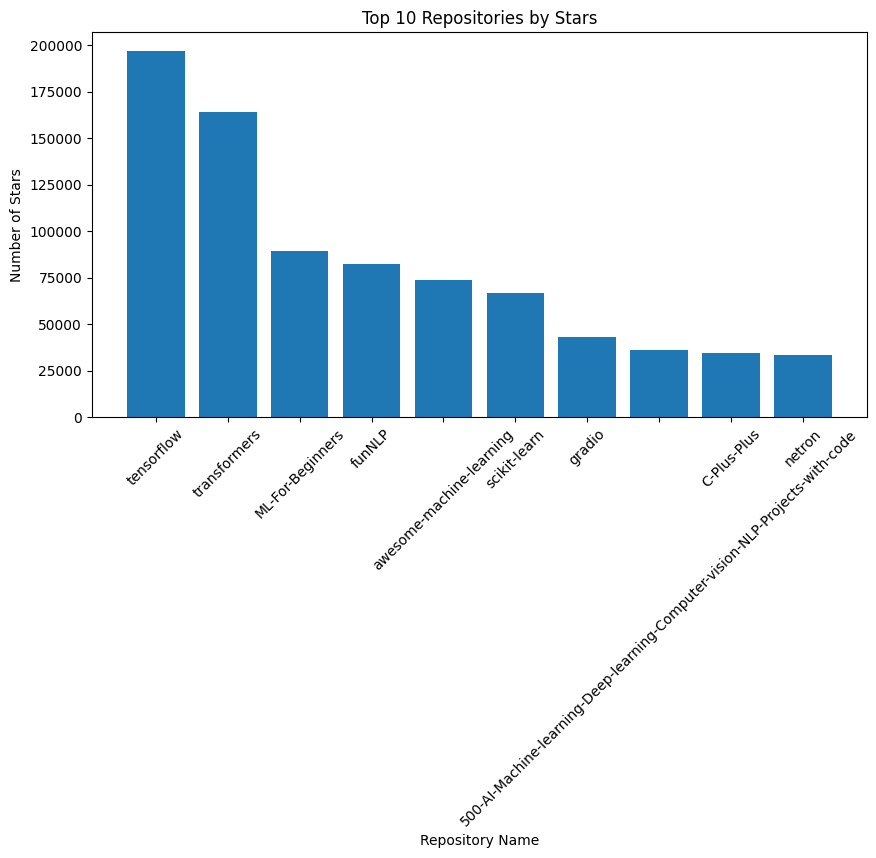

In [89]:
# 1. Bar chart for top 10 most popular repositories
query_top_stars = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""
df_top_stars = pd.read_sql_query(query_top_stars, conn)

plt.figure(figsize=(10, 5))
plt.bar(df_top_stars['name'], df_top_stars['stars'])
plt.title('Top 10 Repositories by Stars')
plt.xlabel('Repository Name')
plt.ylabel('Number of Stars')
plt.xticks(rotation=45)
plt.show()



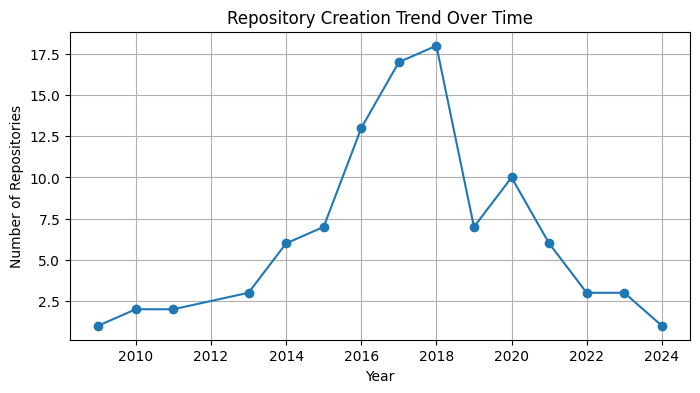

In [90]:
# 2. Line chart for repository creation trends over time
query_trends = """
SELECT created_date
FROM Repositories;
"""
df_trends = pd.read_sql_query(query_trends, conn)

# Convert to datetime and count repos per year
df_trends['created_date'] = pd.to_datetime(df_trends['created_date'])
yearly_counts = df_trends['created_date'].dt.year.value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o')
plt.title('Repository Creation Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Repositories')
plt.grid(True)
plt.show()

#Step 8: Interpret Results

In [91]:
# Print summary data to write findings
print("Top repos:\n", df_top_stars[['name', 'stars']].head(5))
print("\nLanguage distribution:\n", df_grouping)

Top repos:
                        name   stars
0                tensorflow  197087
1              transformers  164166
2          ML-For-Beginners   89443
3                    funNLP   82501
4  awesome-machine-learning   74036

Language distribution:
            language  repo_count
0               C++          12
1  Jupyter Notebook          18
2            Python          30
3           Unknown          23


#### 1. Most Popular Repositories
* The top repositories in the dataset are dominated by major open-source tools and frameworks.
* A few very popular projects hold most of the total stars, showing that community focus is concentrated on key development tools.

#### 2. Programming Language Trends
* Python and JavaScript are the most common languages in the dataset, both having more than 5 repositories.
* Languages with large developer communities have the highest number of repositories in this analysis.

#### 3. Creation Trends Over Time
* The line chart shows a steady increase in repository creation over the years.
* This trend reflects the overall growth of open-source projects and developer activity over time.

#GitHub Repository: https://github.com/alhoussainmohamed11-star/final_project_data_analysis.git

### Ethics Reflection

#### 1. Why is it important to verify data collected from public APIs?
* Public APIs can contain missing, outdated, or incomplete data.
* Verifying the data ensures that the analysis is based on accurate and real information, preventing wrong assumptions.

#### 2. Why should data analysts document the source of their data?
* Documenting data sources builds trust and makes the work transparent.
* It allows other team members to reproduce the analysis and verify the steps taken.

#### 3. How can missing or inaccurate data affect data analysis and decision-making?
* Inaccurate data leads to wrong conclusions and misleading trends in the final report.
* Making business decisions based on bad data can result in wasted resources and poor strategic planning.